<a href="https://colab.research.google.com/github/nehaa511/customer-churn-prediction/blob/main/churn_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel("Telco_customer_churn.xlsx")
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [10]:
print(df.shape)
df.info()

(7043, 33)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Serv

In [11]:
print(df.columns.tolist())

['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value', 'Churn Score', 'CLTV', 'Churn Reason']


In [12]:
for c in df.columns:
  print(c)

CustomerID
Count
Country
State
City
Zip Code
Lat Long
Latitude
Longitude
Gender
Senior Citizen
Partner
Dependents
Tenure Months
Phone Service
Multiple Lines
Internet Service
Online Security
Online Backup
Device Protection
Tech Support
Streaming TV
Streaming Movies
Contract
Paperless Billing
Payment Method
Monthly Charges
Total Charges
Churn Label
Churn Value
Churn Score
CLTV
Churn Reason


Churn Label
No     5174
Yes    1869
Name: count, dtype: int64
Churn Label
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


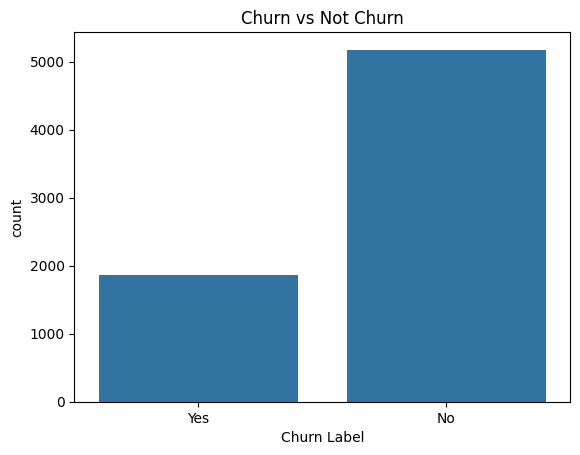

In [13]:
print(df["Churn Label"].value_counts())
print(df["Churn Label"].value_counts(normalize=True) * 100)

sns.countplot(x="Churn Label", data=df)
plt.title("Churn vs Not Churn")
plt.show()

In [14]:
print(df.isnull().sum()[df.isnull().sum() > 0])
df["Total Charges"] = pd.to_numeric(df["Total Charges"], errors="coerce")
print(df["Total Charges"].isnull().sum())
df["Total Charges"] = df["Total Charges"].fillna(0)

Churn Reason    5174
dtype: int64
11


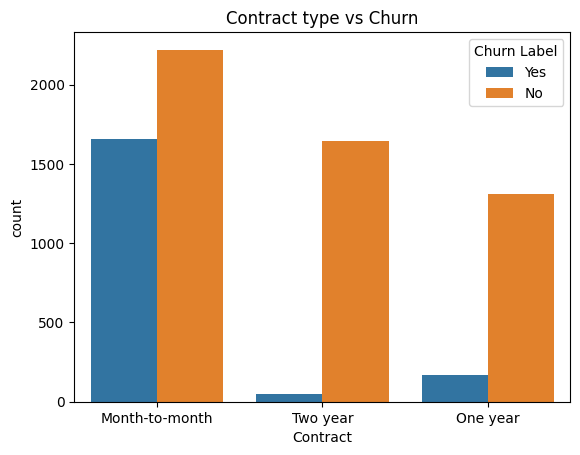

In [15]:
sns.countplot(x="Contract", hue="Churn Label", data=df)
plt.title("Contract type vs Churn")
plt.show()

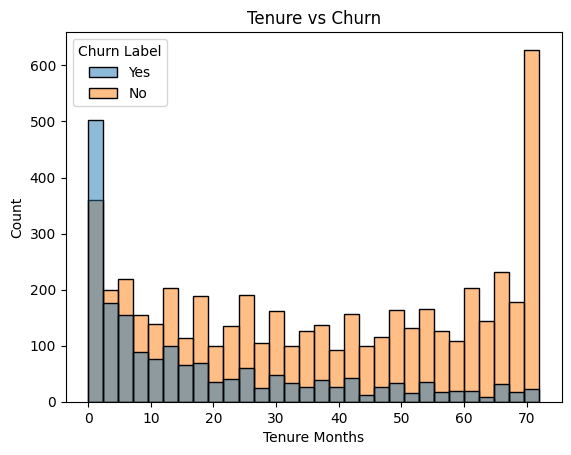

In [16]:
sns.histplot(data=df, x="Tenure Months", hue="Churn Label", bins=30)
plt.title("Tenure vs Churn")
plt.show()

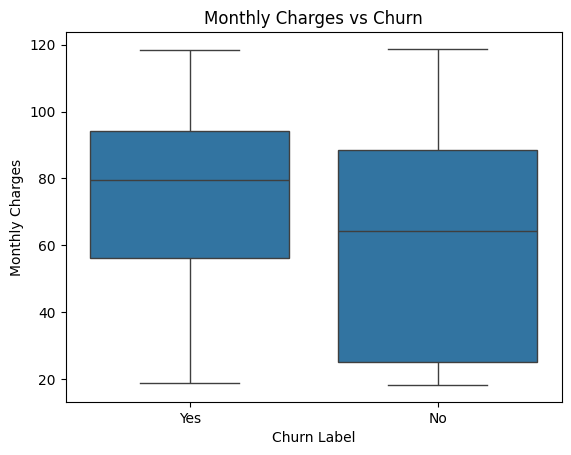

In [17]:
sns.boxplot(x="Churn Label", y="Monthly Charges", data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

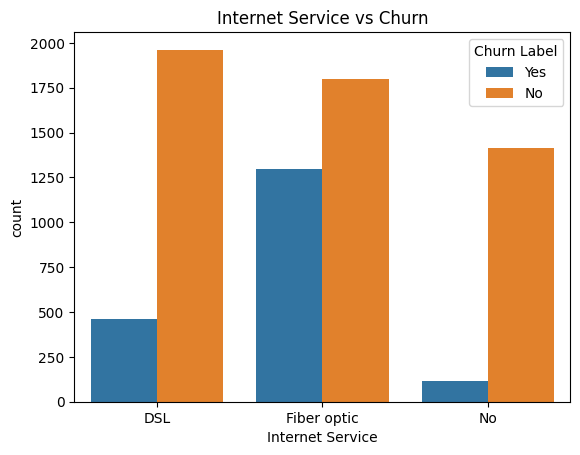

In [18]:
sns.countplot(x="Internet Service", hue="Churn Label", data=df)
plt.title("Internet Service vs Churn")
plt.show()

Accuracy: 0.7430801987224982
              precision    recall  f1-score   support

           0       0.90      0.73      0.81      1035
           1       0.51      0.78      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409



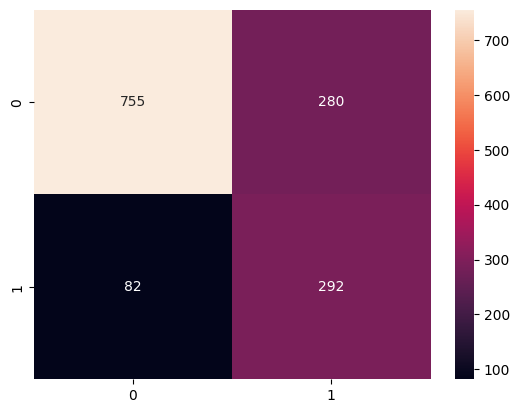

Churn kam karne wale:
 Tenure Months       -1.201257
Monthly Charges     -0.850009
Dependents_Yes      -0.690324
Contract_Two year   -0.607622
Contract_One year   -0.321767
dtype: float64
Churn badhane wale:
 Multiple Lines_Yes              0.193927
Streaming TV_Yes                0.238329
Streaming Movies_Yes            0.249033
Total Charges                   0.505918
Internet Service_Fiber optic    0.691427
dtype: float64


In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# split + scaling
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# model
model = LogisticRegression(max_iter=1000, class_weight="balanced")
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# result
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d")
plt.show()

# important features
imp = pd.Series(model.coef_[0], index=X.columns).sort_values()
print("Churn kam karne wale:\n", imp.head(5))
print("Churn badhane wale:\n", imp.tail(5))